<a href="https://colab.research.google.com/github/navspeak/ML/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

# Seed for reproducibility
np.random.seed(0)

# Generate random data
X1 = 20 * np.random.rand(100, 1)
X2 = X1 + np.random.randn(100, 1) * 0.0001  # X2 is highly correlated with X1

# True coefficients
true_coefs = np.array([3, 5])
y = 3 * X1 + 5 * X2 + 6 + np.random.randn(100, 1)

# Combine features into a single matrix
X = np.hstack([X1, X2])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Add a column of ones to include the intercept term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Gradient Descent parameters
learning_rate = 0.001
n_iterations = 1000
m = X_b.shape[0]
lambda_reg = 1

# Initialize theta (parameters)
theta = np.random.randn(3, 1)

# Gradient Descent
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y) + lambda_reg * np.sign(theta)
    gradients[0] -= lambda_reg * np.sign(theta[0])  # No regularization for the intercept term
    theta = theta - learning_rate * gradients

# Display the results
print("Theta (parameters) found by gradient descent:")
print(theta)

# Predictions
y_pred = X_b.dot(theta)

# Calculate and print the mean squared error
mse = np.mean((y - y_pred) ** 2)
print("Mean Squared Error:", mse)


Theta (parameters) found by gradient descent:
[[2.66111659]
 [4.97462028]
 [3.26448145]]
Mean Squared Error: 3.88918127375986


In [ ]:
from sklearn.linear_model import Lasso

# Lasso regression with a regularization parameter
lasso_reg = Lasso(alpha=1)
lasso_reg.fit(X_train, y_train)
y_lasso_pred = lasso_reg.predict(X_test).reshape(-1, 1)

# Print coefficients
print("Lasso Regression Coefficients:", lasso_reg.coef_)
print("Intercept:", lasso_reg.intercept_)

# Calculate and print the mean squared error
mse_lasso = np.mean((y_test - y_lasso_pred) ** 2)
print("Mean Squared Error with Lasso Regression:", mse_lasso)


Lasso Regression Coefficients: [7.95458910e+00 4.92159829e-07]
Intercept: [6.23841813]
Mean Squared Error with Lasso Regression: 0.9445565399639475


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


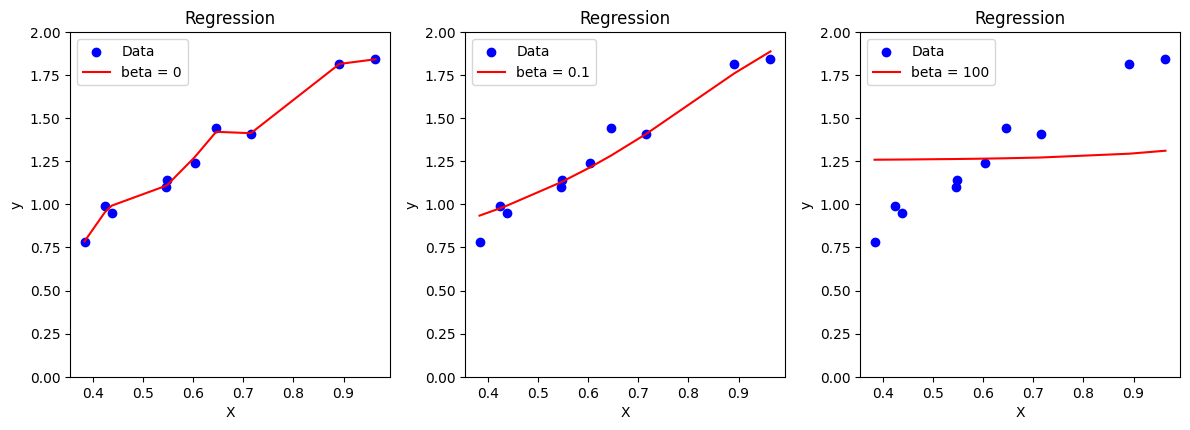

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generate some data
np.random.seed(0)
n_samples = 10
X = np.sort(np.random.rand(n_samples))
y = 2 * (X) + np.random.normal(0, 0.1, n_samples)

# Polynomial degree
degree = 10

# Regularization strengths
alphas = [0, 0.1,100]

# Plotting
plt.figure(figsize=(12, 8))

for i, alpha in enumerate(alphas):
    # Create polynomial features
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
    model.fit(X[:, np.newaxis], y)
    y_plot = model.predict(X[:, np.newaxis])

    # Plot data and prediction
    plt.subplot(2, 3, i + 1)
    plt.scatter(X, y, color='blue', label='Data')
    plt.plot(X, y_plot, color='red', label=f'beta = {alpha}')
    plt.ylim(0, 2)
    plt.title(f'Regression')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()

plt.tight_layout()
plt.show()
